# jumat

## 1. Preparation

### 1.1 import library

In [630]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 import dataset

In [631]:
df = pd.read_csv('Iris.csv')

### 1.3 Check Info

In [632]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### 1.4 Drop Columns Id

In [633]:
df = df.drop('Id', axis=1)

### 1.5 Check Missing Value

In [634]:
print('NIlai Hilang:    ', df.isnull().sum().sum())

NIlai Hilang:     0


### 1.6 Check Duplicated Value

In [635]:
print('Nilai Duplikat:  ', df.duplicated().sum())

Nilai Duplikat:   3


In [636]:
df = df.drop_duplicates()

In [637]:
df.duplicated().sum()

np.int64(0)

### 1.7 Encode Columns Species

In [638]:
print("Sebelum after:   ", df['Species'].unique())
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

print("Setelah before:  ", df['Species'].unique())

Sebelum after:    ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Setelah before:   [0 1 2]


## 2. EDA

### 2.1 Distribution of Column Species

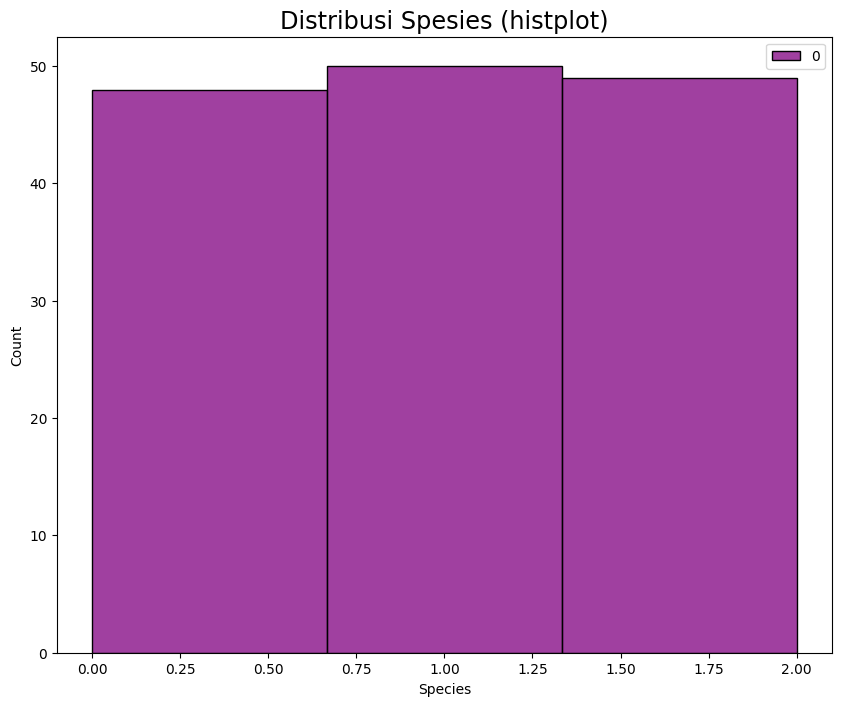

In [639]:
plt.figure(figsize=(10,8))
plt.title('Distribusi Spesies (histplot)', fontsize='xx-large')
sns.histplot(data=df, x=df['Species'], bins=3, color='purple')
plt.legend((0,2))
plt.show()

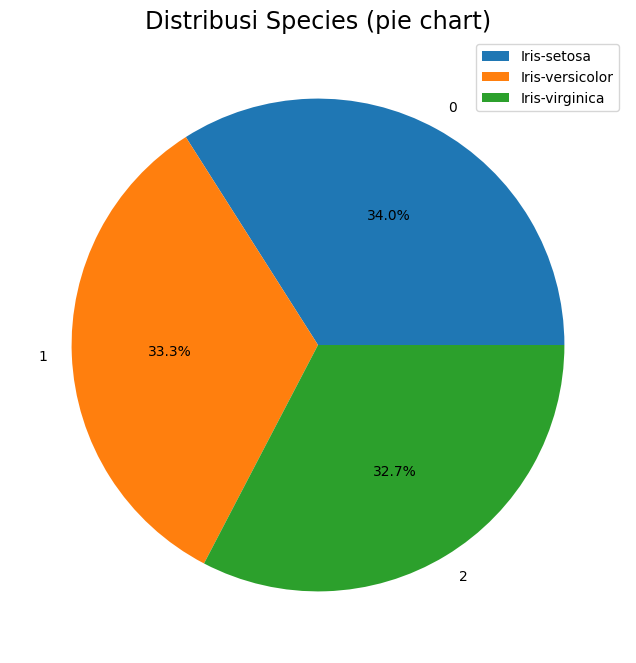

In [640]:
plt.figure(figsize=(10,8))
plt.pie(df['Species'].value_counts(), labels=df['Species'].unique(), autopct='%1.1f%%')
plt.title('Distribusi Species (pie chart)', fontsize='xx-large')
plt.legend(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
plt.show()

### 2.2 Correlation Data Frame

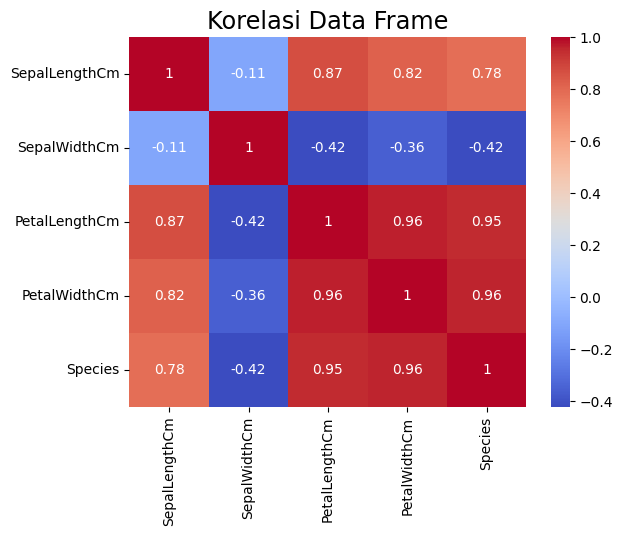

In [641]:
plt.title('Korelasi Data Frame', fontsize='xx-large')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### 2.3 Distribution Feature

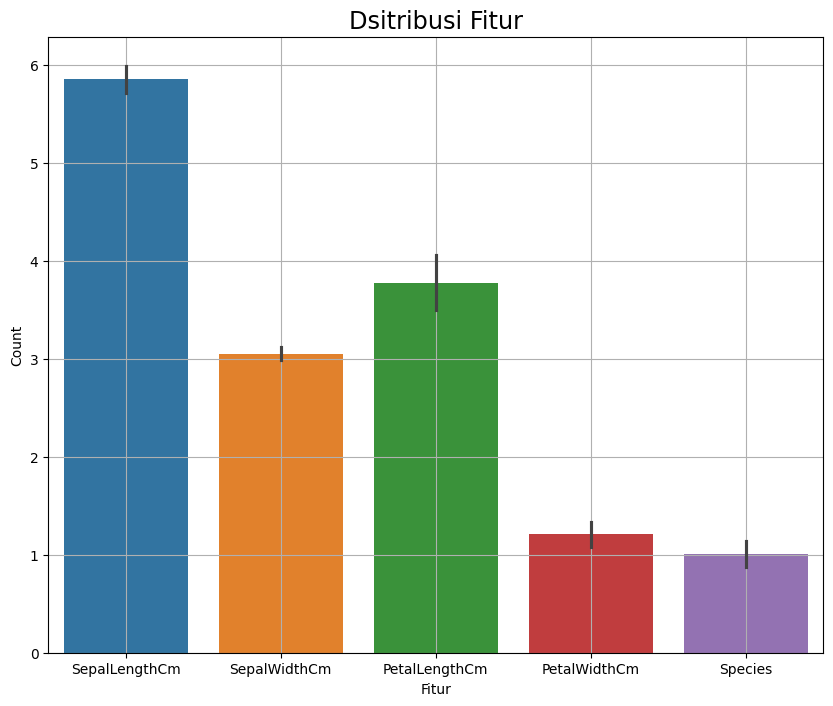

In [642]:
plt.figure(figsize=(10,8))
sns.barplot(df)
plt.ylabel('Count')
plt.xlabel('Fitur')
plt.title('Dsitribusi Fitur', fontsize='xx-large')
plt.grid(True)
plt.show()

### 2.4 Check Outlier

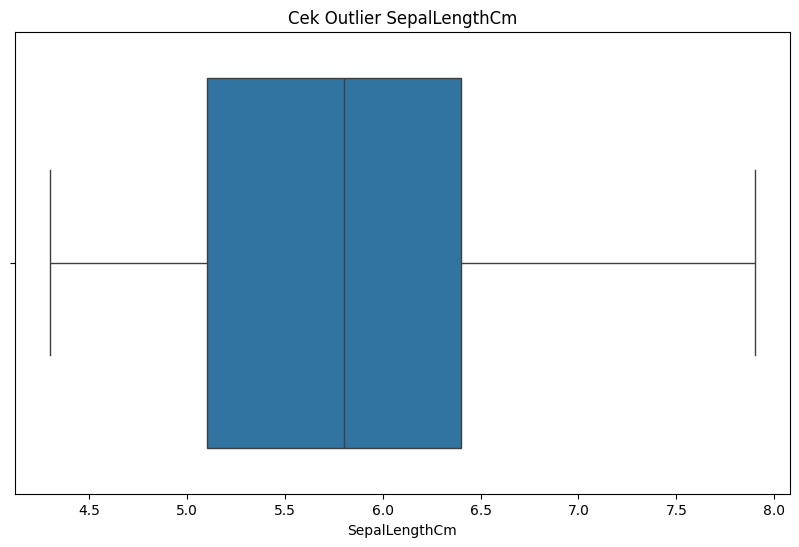

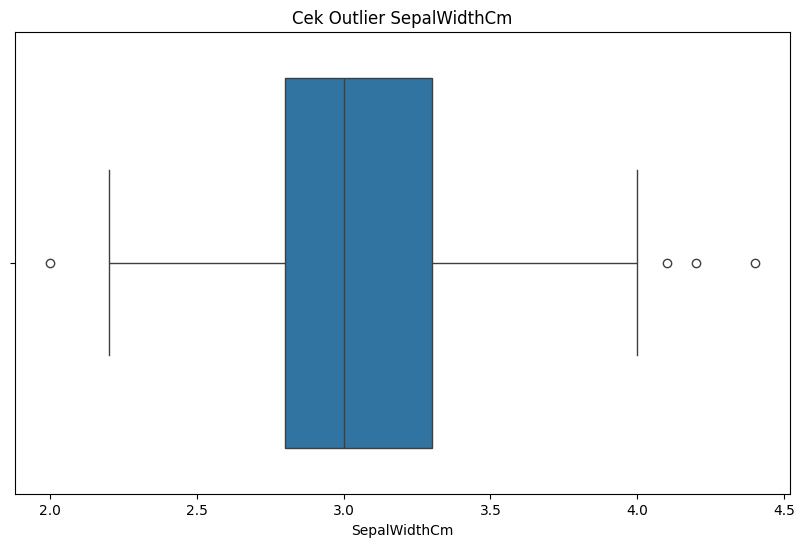

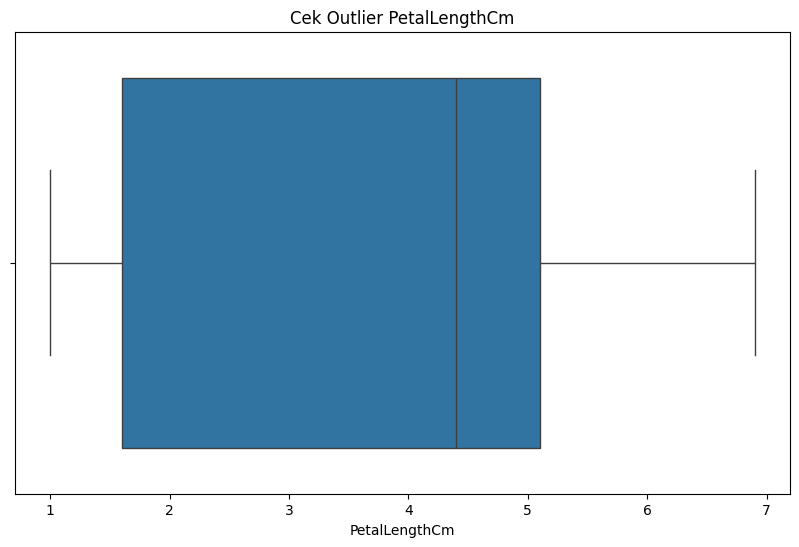

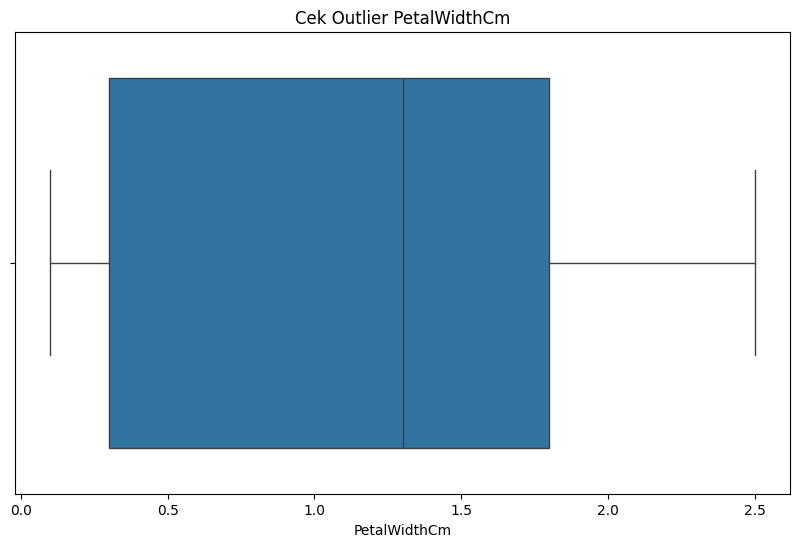

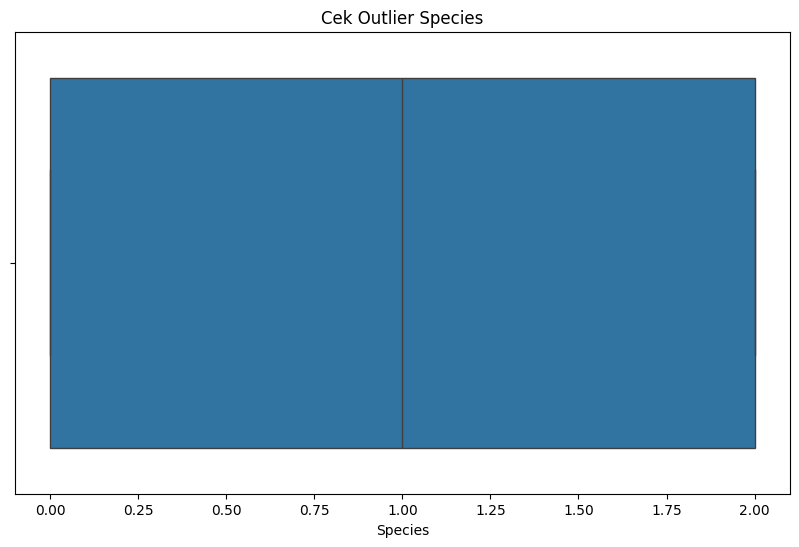

In [643]:
for col in df:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[col])
    plt.title(f'Cek Outlier {col}')
    plt.show()

*Ada outlier di kolom SepalWidthCm*

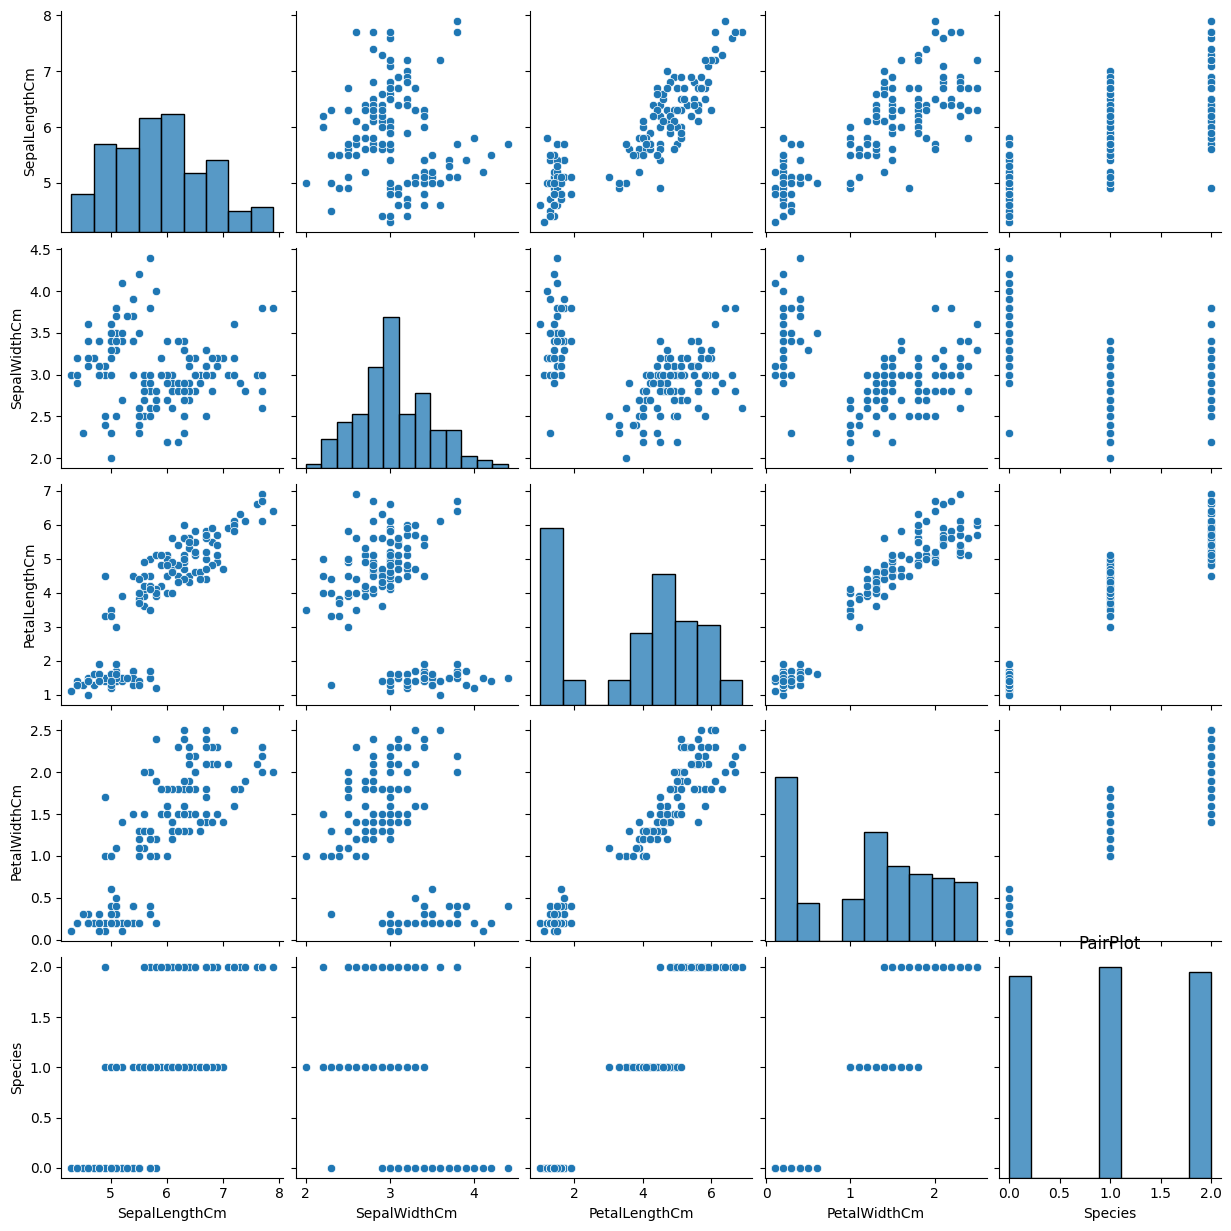

In [644]:
sns.pairplot(df)
plt.title('PairPlot')
plt.show()

## Modeling

In [645]:
X = df.drop('Species', axis=1).values

In [646]:
# satndaarization

mean = X.mean()
std = np.std(X)

X_scaled = (X - mean) / std

In [647]:
# K-Means Clustering 
def kmean(data, k=3, max_itter=1000):
    random_centroid = data[np.random.choice(data.shape[0], k, replace=False)]

    for _ in range(max_itter):
        distance = np.array([np.linalg.norm(data - random_centroid[i] , axis=1) for i in range(k)])
        cluster = np.argmin(distance, axis=0)

        new_centroid = np.array([data[cluster == i].mean(axis=0) for i in range(k)])

        if np.all(random_centroid == new_centroid):
            break
        random_centroid = new_centroid
    return cluster, random_centroid

clusters, centroids = kmean(X_scaled, k=3, max_itter=1000)

## Visualisation

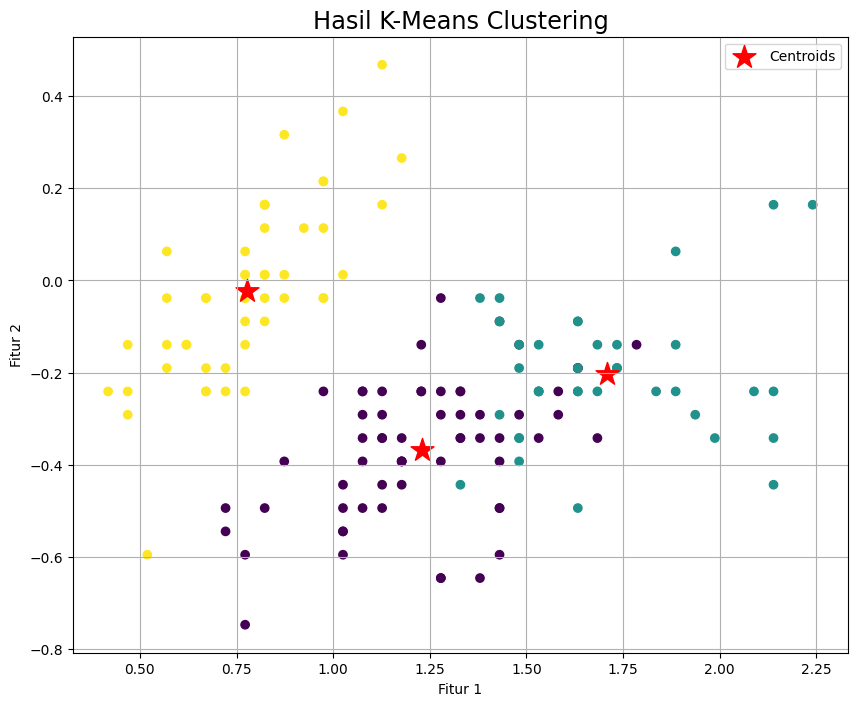

In [649]:
# visualisasi kmeans
plt.figure(figsize=(10,8))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], s=300, c='red', label='Centroids', marker='*')
plt.title('Hasil K-Means Clustering', fontsize='xx-large')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation

In [651]:
def hitung_silhouette(data, labels, centroids):
    n = len(data)
    if len(np.unique(labels)) < 2: return 0
    
    silhouette_vals = []
    for i in range(n):
        same_cluster = data[labels == labels[i]]
        if len(same_cluster) > 1:
            a_i = np.mean(np.linalg.norm(same_cluster - data[i], axis=1))
        else:
            a_i = 0
            
        b_i = float('inf')
        for k in range(len(centroids)):
            if k == labels[i]: continue
            other_cluster = data[labels == k]
            if len(other_cluster) > 0:
                dist_other = np.mean(np.linalg.norm(other_cluster - data[i], axis=1))
                b_i = min(b_i, dist_other)
        
        s_i = (b_i - a_i) / max(a_i, b_i)
        silhouette_vals.append(s_i)
        
    return np.mean(silhouette_vals)
sh = hitung_silhouette(X_scaled, clusters, centroids)
print("Silhouette Score: ", sh)

Silhouette Score:  0.56003817789559


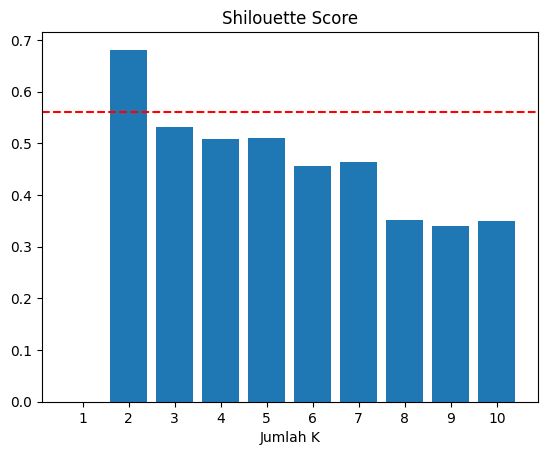

In [657]:
plt.bar(range(1,11), [hitung_silhouette(X_scaled, kmean(X_scaled, k=i)[0], kmean(X_scaled, k=i)[1]) for i in range(1, 11)])
plt.axhline(y=np.mean(sh), c='red', linestyle='--')
plt.title('Shilouette Score')
plt.xlabel('Jumlah K')
plt.xticks(range(1,11))
plt.show()